In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def wrangler(data_path:str) -> pd.DataFrame:
    raw_data_file = Path(data_path).resolve()

    df = pd.read_csv(raw_data_file)

    # Fix column formatting
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    # Fix string formatting
    col_str = tuple(df.dtypes[df.dtypes == "str"].index)
    for col in col_str:
        df[col] = df[col].str.lower().str.replace(" ", "_")

    return df

In [3]:
df = wrangler("./data.csv")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [5]:
df.nunique()

make                   48
model                 914
year                   28
engine_fuel_type       10
engine_hp             356
engine_cylinders        9
transmission_type       5
driven_wheels           4
number_of_doors         3
market_category        71
vehicle_size            3
vehicle_style          16
highway_mpg            59
city_mpg               69
popularity             48
msrp                 6049
dtype: int64

In [6]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:3])
    print()

make
<ArrowStringArray>
['bmw', 'audi', 'fiat']
Length: 3, dtype: str

model
<ArrowStringArray>
['1_series_m', '1_series', '100']
Length: 3, dtype: str

year
[2011 2012 2013]

engine_fuel_type
<ArrowStringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)']
Length: 3, dtype: str

engine_hp
[335. 300. 230.]

engine_cylinders
[6. 4. 5.]

transmission_type
<ArrowStringArray>
['manual', 'automatic', 'automated_manual']
Length: 3, dtype: str

driven_wheels
<ArrowStringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive']
Length: 3, dtype: str

number_of_doors
[2. 4. 3.]

market_category
<ArrowStringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-performance']
Length: 3, dtype: str

vehicle_size
<ArrowStringArray>
['compact', 'midsize', 'large']
Length: 3, dtype: str

vehicle_style
<ArrowStringArray>
['coupe', 'convertible', 'sedan']
Length: 3, dtype:

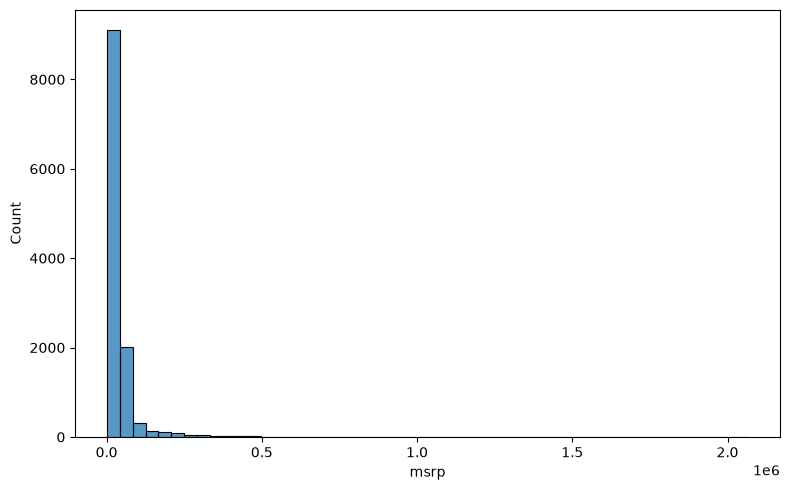

In [10]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))

sns.histplot(df["msrp"], bins=50, ax=ax)

plt.tight_layout()

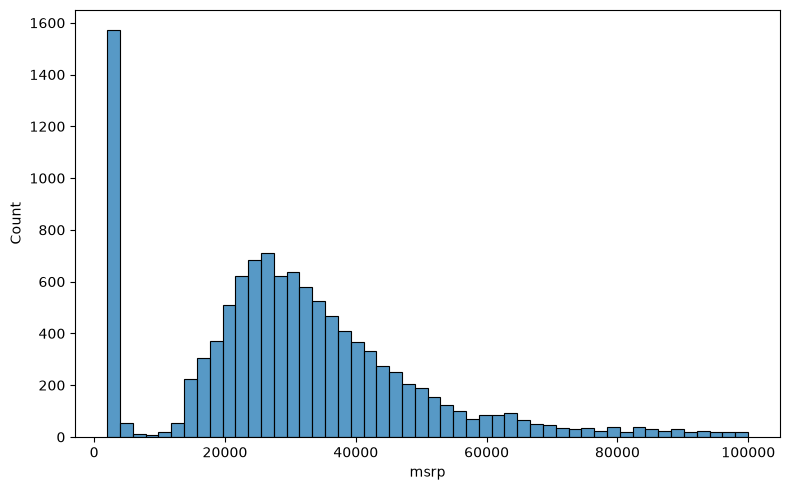

In [11]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))

sns.histplot(df["msrp"][df["msrp"] < 100_000], bins=50, ax=ax)

plt.tight_layout()

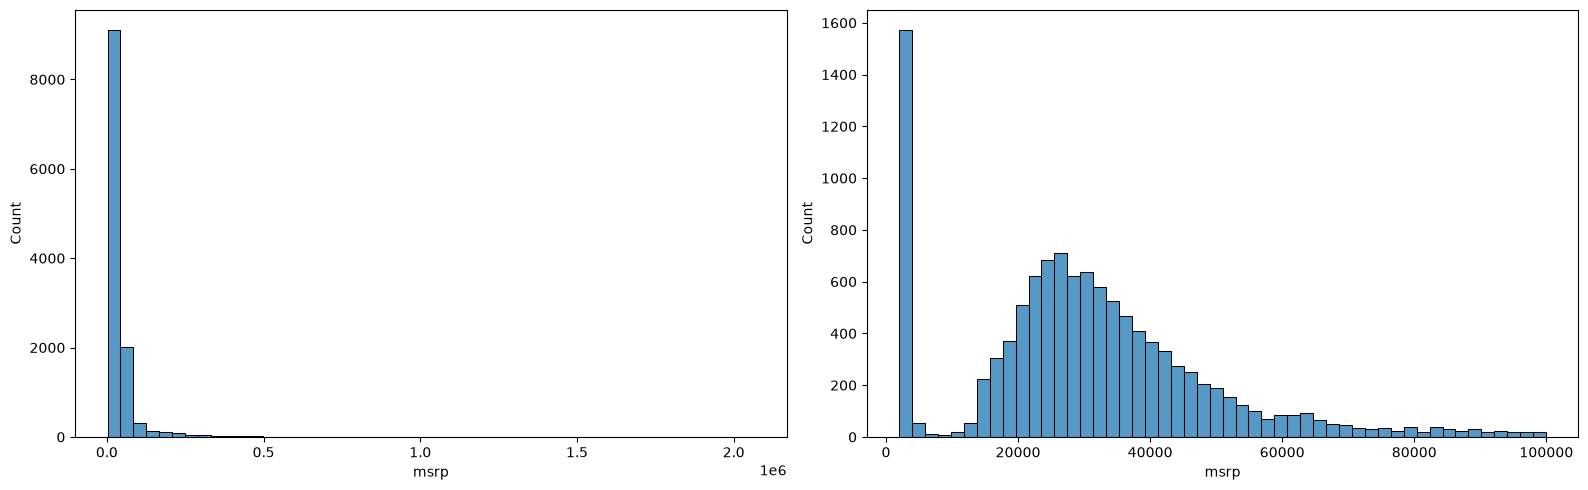

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(1600, 500, "px"))

sns.histplot(df["msrp"], bins=50, ax=ax[0])
sns.histplot(df["msrp"][df["msrp"] < 100_000], bins=50, ax=ax[1])

plt.tight_layout()

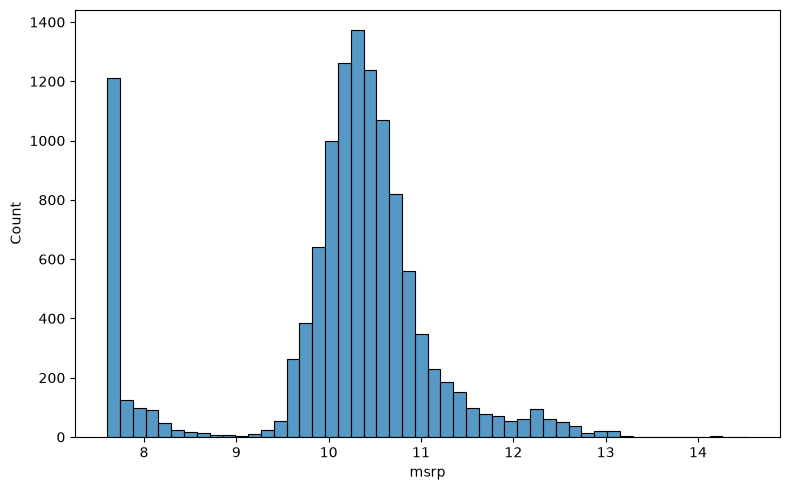

In [14]:
# Get natural logarithm of prices
price_logs = np.log1p(df["msrp"]) 

fig, ax = plt.subplots(figsize=(800, 500, "px"))
sns.histplot(price_logs, bins=50, ax=ax)
plt.tight_layout()

In [16]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64